Installing Lazyslide module

In [2]:
!pip install lazyslide

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

Downloading Whole Slide Image

GTEX-1117F-0526.svs: reconstructing file:   0%|          |  0.00B / 37.3MB            

GTEX-1117F-0526.svs: downloading bytes:           |  0.00B            

GTEX-1117F-0526.zarr.zip: reconstructing file:   0%|          |  0.00B / 2.82MB            

GTEX-1117F-0526.zarr.zip: downloading bytes:           |  0.00B            

WSI: /root/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/GTEX-1117F-0526.svs
Reader: openslide
Dimensions: 19958×19919 (h×w), 3 Pyramids
Pixel physical size: 0.4942 MPP
SpatialData object, with associated Zarr store: /root/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/GTEX-1117F-0526.zarr
├── Shapes
│     ├── 'annotations': GeoDataFrame shape: (14, 5) (2D shapes)
│     ├── 'dl-tissue': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (253, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (2, 2) (2D shapes)
└── Tables
      ├── 'resnet50_tiles': AnnData (253, 2048)
      └── 'uni2_tiles': AnnData (253, 1536)
with coordinate systems:
    ▸ 'global', with elements:
        annotations (Shapes), dl-tissue (Shapes), tiles (Shapes), tissues (Shapes)
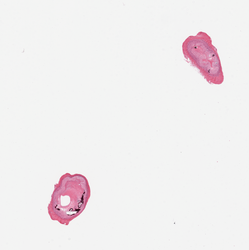

In [3]:
import lazyslide as zs

wsi = zs.datasets.gtex_artery()
wsi

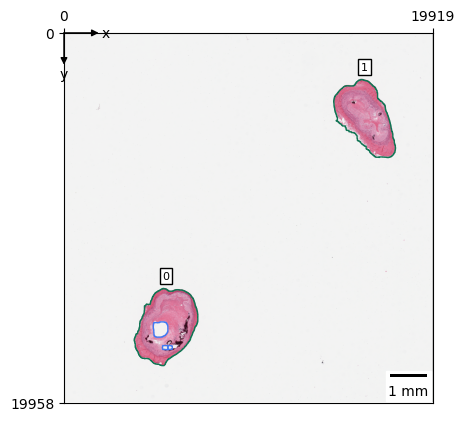

In [4]:
#Visualizing tissues
zs.pl.tissue(wsi)

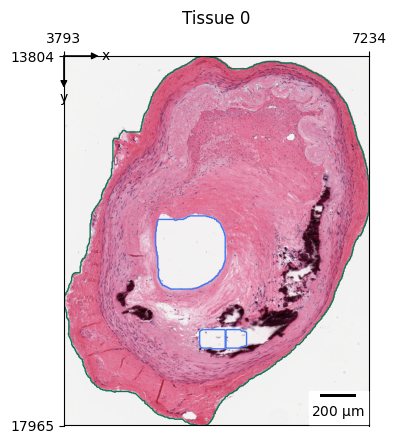

In [ ]:
#Zooming on a specific tissue
zs.pl.tissue(wsi, tissue_id=0)

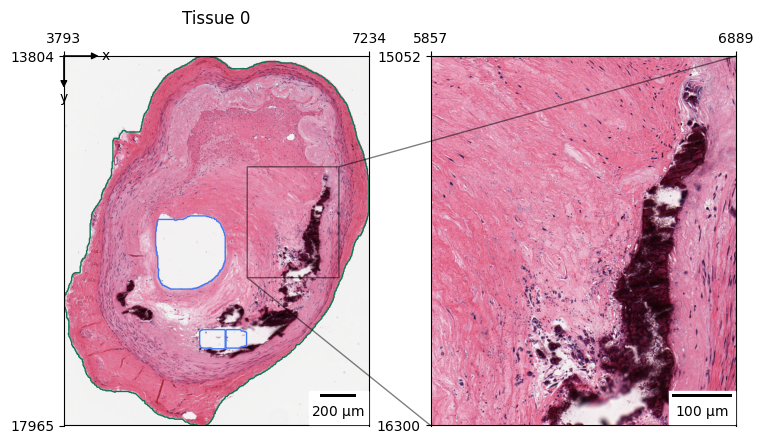

In [ ]:
#Zooming on a specific region of our tissue using the zoom parameter

zs.pl.tissue(wsi, tissue_id=0, zoom=[0.6, 0.9,0.3,0.6])

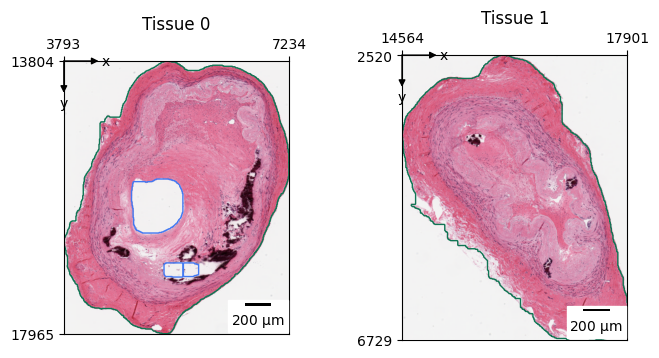

In [ ]:
#Displaying all the tissue pieces at once
zs.pl.tissue(wsi, tissue_id="all")

In [ ]:
zs.pp.tile_tissues(wsi, 256, overlap=0.1, mpp=0.5, key_added= "tile_overlap_0.1")
wsi.tile_spec("tile_overlap_0.1")

Tile at 0.5 mpp, 256×256 (h×w)
Stride: 230×230 (26×26 overlap)
Operation size: 259×259, level=0
Base size: 259×259, level=0
Target tissue: 'tissues'

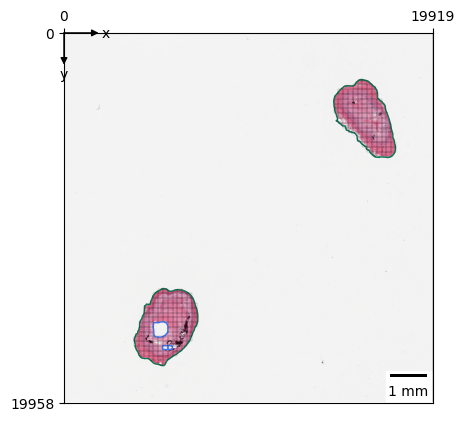

In [ ]:
#Visualizing our tiled tissues
zs.pl.tiles(wsi)

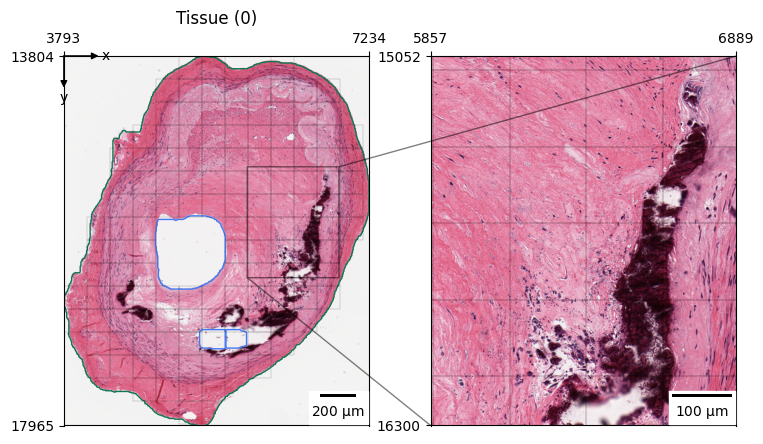

In [ ]:

zs.pl.tiles(wsi, tissue_id=0, zoom=[0.6,0.9,0.3,0.6])

In [ ]:
#Pathprofiler allows us to identify the quality of our image tiles
zs.tl.tile_prediction(wsi,'pathprofilerqc')

PathProfiler/PathProfiler_patch_quality_(…): reconstructing file:   0%|          |  0.00B / 46.2MB            

PathProfiler/PathProfiler_patch_quality_(…): downloading bytes:           |  0.00B            

Output()

In [ ]:
wsi["tiles"].head()

,tile_id,tissue_id,geometry,diagnostic_quality,visual_cleanliness,focus_issue,staining_issue,tissue_folding_present,misc_artifacts_present
0,0,0,"POLYGON ((4052 16394, 4052 16653, 3793 16653, ...",0.303420,-0.156583,0.185155,0.606920,-0.010599,0.589388
1,1,0,"POLYGON ((4052 16653, 4052 16912, 3793 16912, ...",0.484279,-0.130888,0.128396,0.559105,0.070007,0.489406
2,2,0,"POLYGON ((4311 15617, 4311 15876, 4052 15876, ...",0.403935,-0.068042,0.040358,0.438769,0.049033,0.538063
3,3,0,"POLYGON ((4311 15876, 4311 16135, 4052 16135, ...",0.470957,-0.124676,0.048038,0.456844,0.062897,0.570481
4,4,0,"POLYGON ((4311 16135, 4311 16394, 4052 16394, ...",0.331370,-0.092984,0.077912,0.372388,-0.001795,0.614351


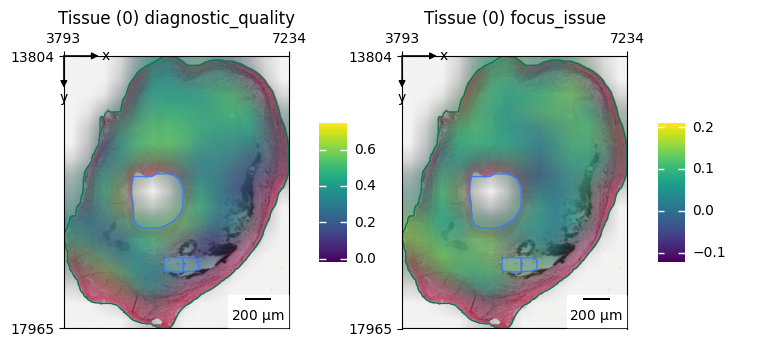

In [ ]:
#Visualizing the diagnostic quality and focus_issue (tile_features)of our tissues
zs.pl.tiles(wsi, tissue_id=0, color=['diagnostic_quality','focus_issue'], smooth=True)

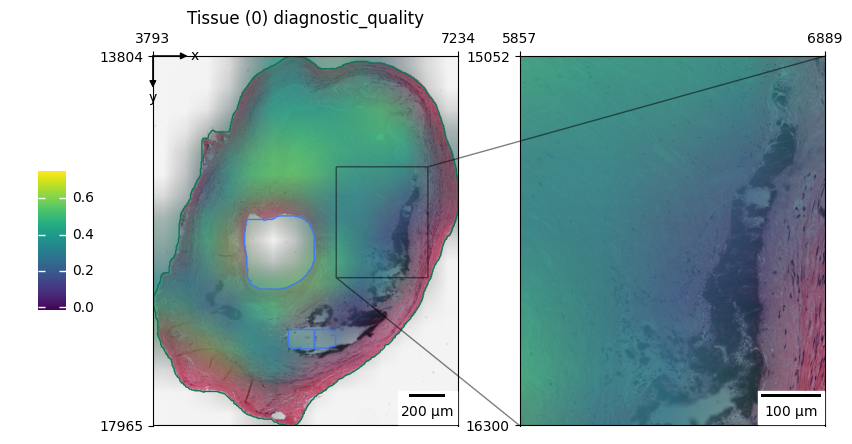

In [ ]:
zs.pl.tiles(wsi, tissue_id=0, color="diagnostic_quality", zoom=[0.6,0.9,0.3,0.6], smooth=True)

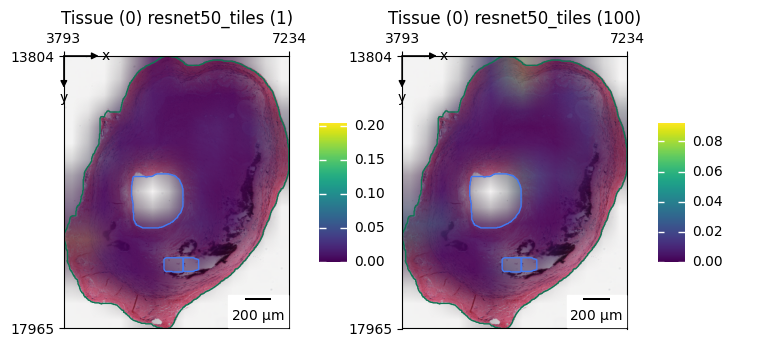

In [ ]:
#Plotting the tile features extracted by the resnet50 model
zs.pl.tiles(wsi, tissue_id=0, feature_key="resnet50", color=["1","100"], smooth=True)

In [ ]:
wsi["annotations"].head()

,tissue_id,id,objectType,name,geometry
0,0,f56c25e5-ce21-4d42-bcda-b67b9fd98870,annotation,sclerosis,"POLYGON ((4631.5 16627, 4629 16628, 4594 16628..."
1,0,c799bbe2-5a08-467a-9e5d-6376b718cee8,annotation,sclerosis,"POLYGON ((4528 16331, 4527.67 16331.17, 4527 1..."
2,0,bcc06960-003b-43f0-9e88-496579dffd34,annotation,sclerosis,"POLYGON ((5598.73 17098.36, 5596 17102, 5594.8..."
3,0,e3ba7093-e973-424a-9c77-66caa03569fb,annotation,sclerosis,"POLYGON ((5964 17053, 5956 17055, 5954.2 17056..."
4,0,370d0dc5-f5d1-40d9-bce6-d47f63fc4cbc,annotation,sclerosis,"POLYGON ((5649 16849, 5652 16848, 5655 16848, ..."


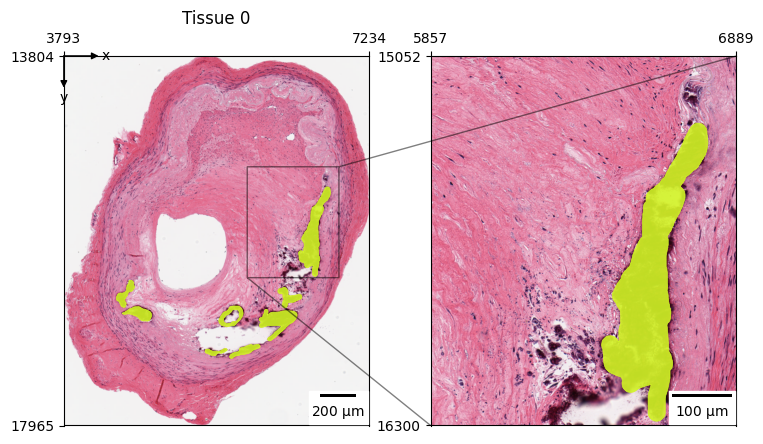

In [ ]:
#Lazyslide allows us to visualize the annotations assigned to our tissues
zs.pl.annotations(wsi,"annotations", tissue_id=0, zoom=[0.6,0.9,0.3,0.6])

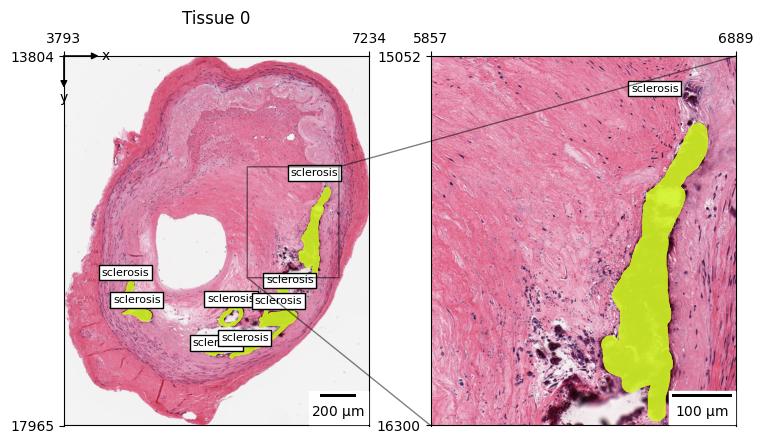

In [ ]:
zs.pl.annotations(wsi, "annotations", tissue_id=0, label="name", zoom=[0.6,0.9,0.3,0.6])

DECLARATIVE  VISUALIZATION IN LAZYSLIDE

<Axes: >

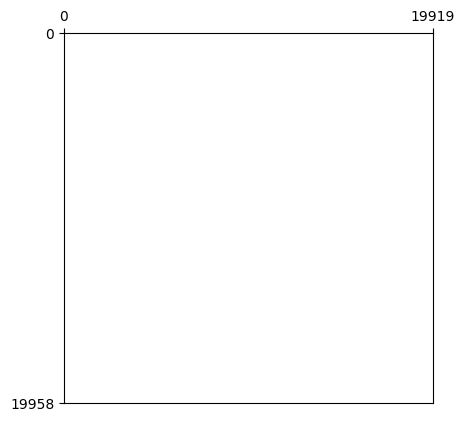

In [ ]:
#Lazyslide allows us to implement an fast plotting system to help visualize WSI

#Building an empty viewer
v = zs.pl.WSIViewer(wsi)
v.show()

<Axes: >

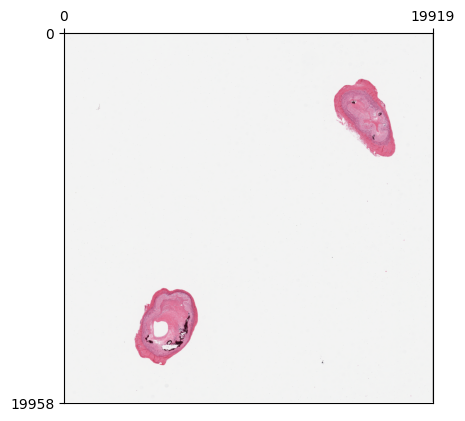

In [ ]:
#Adding the slide image as the background
v.add_image()
v.show()

<Axes: >

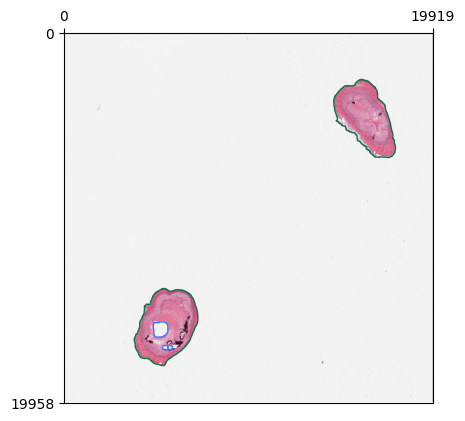

In [ ]:
# Adding contours to our tissues
v.add_contours("tissues")
v.show()

<Axes: >

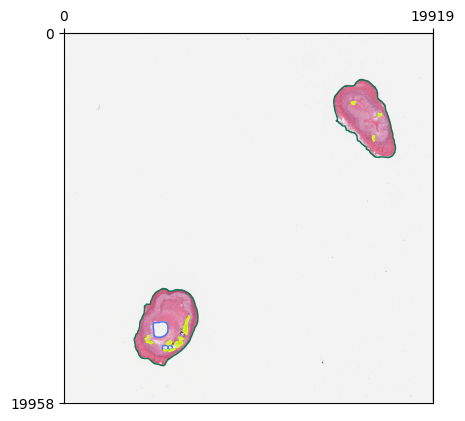

In [ ]:
#Visualizing our annotated regions
v.add_polygons("annotations")
v.show()

<Axes: >

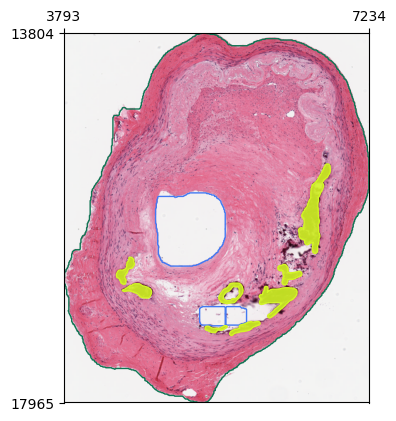

In [ ]:
# Zooming on a particular tissue piece
v.set_tissue_id(0)
v.show()

<Axes: >

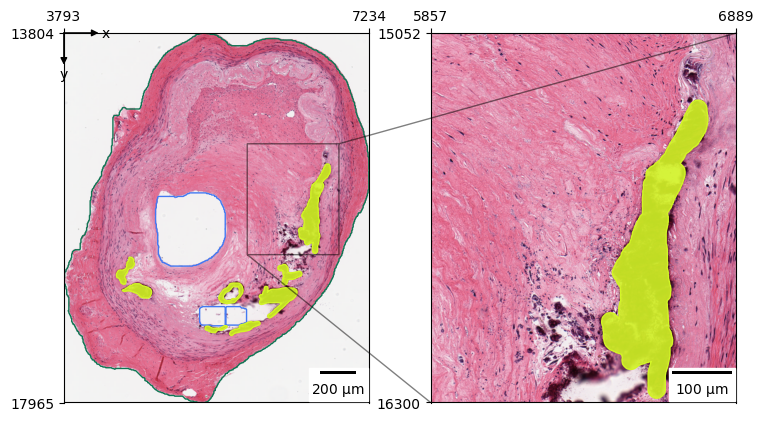

In [ ]:
#Using the zoom parameter to zoom on a specific region of our WSI

v.add_zoom(0.6,0.9,0.3,0.6)
v.add_scalebar()
v.mark_origin()
v.show()